# Group Report Chapter 5: Tables and Charts
* Supporting tables and charts to be used for the `Chapter 5 Analysis and Results`

In [1]:
# Import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

In [2]:
# File paths (current: src/)
RESULTS = Path('../results')
DATA = Path('../data/NSW')


In [3]:
# Palette set explicitly for figures
SURFACE, INK, INK2, MUTED, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
BLUE, ORANGE, RED, BLUE_LIGHT = '#2a78d6', '#eb6834', '#e34948', '#9ec5f4'
plt.style.use('default')
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
                     'text.color': INK, 'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED,
                     'axes.edgecolor': AXIS, 'grid.color': GRID, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

MODELS = ['lightgbm', 'lstm', 'xgboost', 'random_forest', 'prophet', 'baseline']
NAMES = {'lightgbm': 'LightGBM', 'lstm': 'LSTM', 'xgboost': 'XGBoost', 'random_forest': 'Random forest',
         'prophet': 'Prophet', 'baseline': 'Linear regression', 'lightgbm_tuned': 'LightGBM (tuned)',
         'naive': 'Naive (same time yesterday)'}
SEGMENTS = {'overall': 'All of 2019', 'Summer': 'Summer', 'Autumn': 'Autumn', 'Winter': 'Winter',
            'Spring': 'Spring', 'above_18': '18°C and above', 'below_18': 'Below 18°C',
            'is_school_term': 'School term', 'is_school_holiday': 'School holiday'}
SEASON = {1: 'Summer', 2: 'Summer', 12: 'Summer', 3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
          6: 'Winter', 7: 'Winter', 8: 'Winter', 9: 'Spring', 10: 'Spring', 11: 'Spring'}
fmt = lambda d=1: (lambda v: f'{v:,.{d}f}')

In [4]:
# Get Actual

## Load Results

In [5]:
# Segment metrics saved by model_comparison.ipynb; the main results are the runs with radiation_day_before
seg = pd.read_csv(RESULTS / 'model_comparison_by_segment.csv')
main = seg[seg.with_radiation]
by_segment = lambda metric: main.pivot_table(index='model_name', columns='segment', values=metric).loc[MODELS, list(SEGMENTS)]

# Actual 2019 demand, observed temperature, school flag and AEMO forecasts (unscaled)
raw = pd.read_csv(DATA / 'nsw_features_added.csv', parse_dates=['DATETIME']).set_index('DATETIME').sort_index()
y2019 = raw.loc['2019']
actual = y2019['TOTALDEMAND']

# Saved 2019 predictions, aligned to the same half-hours (Prophet's file is written day-first)
def load_predictions(name):
    f = pd.read_csv(RESULTS / f'{name}_predictions.csv')
    dates = f.iloc[:, 0].astype(str)
    f.index = pd.to_datetime(dates, format='ISO8601') if dates.str.match(r'^\d{4}-').all() else pd.to_datetime(dates, dayfirst=True)
    return f.iloc[:, 1].reindex(actual.index)

preds = pd.DataFrame({m: load_predictions(m) for m in MODELS + ['lightgbm_tuned']})
preds['naive'] = raw['TOTALDEMAND'].shift(48).reindex(actual.index)
preds['aemo_dayprior'] = y2019['forecast_dayprior']
preds['aemo_12hr'] = y2019['forecast_12hr_prior']
print(f'{len(seg)} segment rows | {len(actual):,} half-hours in 2019 | LSTM covers {preds.lstm.notna().sum():,}')

108 segment rows | 17,520 half-hours in 2019 | LSTM covers 17,461


In [6]:
# Supporting: accuracy metrics, and the Diebold-Mariano test (absolute loss, Newey-West over one day,
# Harvey-Leybourne-Newbold correction).
# Note: A negative DM statistic means forecast 'a' is more accurate.
def metrics(pred):
    v = pd.concat([actual, pred], axis=1).dropna(); a, p = v.iloc[:, 0], v.iloc[:, 1]
    return {'MAE (MW)': mean_absolute_error(a, p), 'RMSE (MW)': np.sqrt(mean_squared_error(a, p)),
            'MAPE (%)': mean_absolute_percentage_error(a, p) * 100, 'R2': r2_score(a, p), 'Bias (MW)': (a - p).mean()}

def diebold_mariano(a, b, h=48):
    v = pd.concat([actual, a, b], axis=1).dropna()
    d = (v.iloc[:, 0] - v.iloc[:, 1]).abs() - (v.iloc[:, 0] - v.iloc[:, 2]).abs()
    n = len(d)
    var = d.var() * (1 + 2 * sum((1 - k / h) * d.autocorr(k) for k in range(1, h))) / n
    dm = d.mean() / np.sqrt(var) * np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    return {'Mean |e| difference (MW)': d.mean(), 'DM': dm, 'p-value': 2 * stats.t.sf(abs(dm), df=n - 1)}

# Labels for each 2019 half-hour, matching model_comparison.ipynb
masks = {'overall': np.ones(len(actual), bool),
         **{s: (actual.index.month.map(SEASON) == s) for s in ['Summer', 'Autumn', 'Winter', 'Spring']},
         'above_18': (y2019['TEMPERATURE'] >= 18).values, 'below_18': (y2019['TEMPERATURE'] < 18).values,
         'is_school_term': y2019['is_school_term'].astype(bool).values,
         'is_school_holiday': ~y2019['is_school_term'].astype(bool).values}
temp = raw['TEMPERATURE']
change = pd.cut((temp - temp.shift(48)).abs().reindex(actual.index), [0, 2, 5, 8, np.inf], right=False,
                labels=['Under 2°C', '2 to 5°C', '5 to 8°C', '8°C or more'])

## Tables

In [7]:
# Table 5.1 Model accuracy, with the naive forecast for reference
table_51 = pd.DataFrame({NAMES[m]: metrics(preds[m]) for m in MODELS + ['naive']}).T
table_51['Skill vs linear regression (%)'] = (1 - table_51['MAE (MW)'] / table_51.loc['Linear regression', 'MAE (MW)']) * 100
print('Table 5.1: Model Accuracy (2019 test year)')
print(table_51.to_string(float_format=fmt(3)))

Table 5.1: Model Accuracy (2019 test year)
                             MAE (MW)  RMSE (MW)  MAPE (%)    R2  Bias (MW)  Skill vs linear regression (%)
LightGBM                      307.403    463.995     3.745 0.862    -44.216                          19.150
LSTM                          309.326    472.098     3.740 0.857     27.424                          18.645
XGBoost                       311.176    470.545     3.792 0.858    -48.363                          18.158
Random forest                 322.451    493.697     3.928 0.844    -33.124                          15.192
Prophet                       367.335    520.956     4.539 0.826     -3.204                           3.388
Linear regression             380.215    535.989     4.744 0.816    -66.186                           0.000
Naive (same time yesterday)   465.696    687.262     5.746 0.698      0.180                         -22.482


In [8]:
# Table 5.2: Significance of the differences between models, plus the one baseline pair cited in Section 5.2
pairs = [('lightgbm', 'lstm'), ('lightgbm', 'xgboost'), ('lstm', 'xgboost'), ('lightgbm', 'random_forest'),
         ('xgboost', 'random_forest'), ('lstm', 'random_forest'), ('random_forest', 'prophet'), ('prophet', 'baseline')]
table_52 = pd.DataFrame([{'A': NAMES[a], 'B': NAMES[b], **diebold_mariano(preds[a], preds[b])} for a, b in pairs])
print('Table 5.2: Diebold-Mariano tests between models')
print(table_52.to_string(index=False, float_format=fmt(3)))

naive_blend = (preds['naive'] + raw['TOTALDEMAND'].shift(336).reindex(actual.index)) / 2
print('\nLinear regression vs naive blend (Section 5.2):', {k: round(v, 3) for k, v in diebold_mariano(preds['baseline'], naive_blend).items()})

Table 5.2: Diebold-Mariano tests between models
            A                 B  Mean |e| difference (MW)     DM  p-value
     LightGBM              LSTM                    -2.824 -0.472    0.637
     LightGBM           XGBoost                    -3.773 -1.986    0.047
         LSTM           XGBoost                    -0.954 -0.157    0.876
     LightGBM     Random forest                   -15.048 -4.411    0.000
      XGBoost     Random forest                   -11.275 -3.314    0.001
         LSTM     Random forest                   -11.691 -1.843    0.065
Random forest           Prophet                   -44.884 -7.438    0.000
      Prophet Linear regression                   -12.880 -3.696    0.000

Linear regression vs naive blend (Section 5.2): {'Mean |e| difference (MW)': np.float64(-22.015), 'DM': np.float64(-2.017), 'p-value': np.float64(0.044)}


In [9]:
# Table 5.3: MAE (MW) by model + segment
mae = by_segment('mae')
skill = ((1 - mae.loc['lightgbm'] / mae.loc['baseline']) * 100).rename('LightGBM skill (%)')
print('Table 5.3: MAE (MW) by model and segment')
print(pd.concat([mae.rename(index=NAMES), skill.to_frame().T]).rename(columns=SEGMENTS).to_string(float_format=fmt(1)))

Table 5.3: MAE (MW) by model and segment
segment             All of 2019  Summer  Autumn  Winter  Spring  18°C and above  Below 18°C  School term  School holiday
LightGBM                  307.4   452.2   218.7   278.2   283.4           380.6       229.1        294.2           349.5
LSTM                      309.3   459.7   229.6   283.8   269.1           382.8       231.2        286.7           382.6
XGBoost                   311.2   460.5   222.8   278.7   285.7           387.9       229.1        296.3           358.8
Random forest             322.5   474.4   225.4   282.1   311.1           405.0       234.1        305.2           377.6
Prophet                   367.3   519.6   284.1   346.1   322.4           437.1       292.6        344.3           440.8
Linear regression         380.2   523.9   307.1   357.6   334.9           448.1       307.6        361.8           439.2
LightGBM skill (%)         19.2    13.7    28.8    22.2    15.4            15.1        25.5         18.7        

In [10]:
# Table 5.4: MAE rank by model + segment
table_54 = mae.drop(columns='overall').rank().astype(int)
table_54['Times first'] = (table_54 == 1).sum(axis=1)
table_54['Worst rank'] = table_54.drop(columns='Times first').max(axis=1)
print('Table 5.4: Rank within each segment (1 = most accurate)')
print(table_54.rename(index=NAMES, columns=SEGMENTS).to_string())

Table 5.4: Rank within each segment (1 = most accurate)
segment            Summer  Autumn  Winter  Spring  18°C and above  Below 18°C  School term  School holiday  Times first  Worst rank
model_name                                                                                                                         
LightGBM                1       1       1       2               1           2            2               1            5           2
LSTM                    2       4       4       1               2           3            1               4            2           4
XGBoost                 3       2       2       3               3           1            3               2            1           3
Random forest           4       3       3       4               4           4            4               3            0           4
Prophet                 5       5       5       5               5           5            5               6            0           6
Linear regression   

In [11]:
# Table 5.6: LightGBM against the linear baseline by operating condition
# Cut points come from the training years, as in model_baseline.ipynb. The split files hold temperature
# standardised, so the same training rows are taken here in °C (the training split starts on 2 January 2010).
train = raw.loc['2010-01-02':'2017']
conditions = {
    'Temperature': pd.cut(y2019['TEMPERATURE'], [-np.inf, *train['TEMPERATURE'].quantile([.25, .95]), np.inf],
                          labels=['Coolest 25%', 'Middle', 'Hottest 5%']),
    'Change from yesterday': change,
    'Day type': pd.Series(np.where(actual.index.dayofweek >= 5, 'Weekend', 'Weekday'), index=actual.index),
    'Demand level': pd.cut(actual, [-np.inf, *train['TOTALDEMAND'].quantile([1/3, 2/3]), np.inf], labels=['Low', 'Medium', 'High'])}
order = {'Temperature': ['Coolest 25%', 'Hottest 5%'], 'Change from yesterday': list(change.cat.categories),
         'Day type': ['Weekday', 'Weekend'], 'Demand level': ['Low', 'Medium', 'High']}
rows = []
for dim, groups in order.items():
    for g in groups:
        k = (conditions[dim] == g).values
        lr, lg = actual[k] - preds['baseline'][k], actual[k] - preds['lightgbm'][k]
        rows.append({'Dimension': dim, 'Condition': g, 'Half-hours': k.sum(), 'Baseline MAE': lr.abs().mean(),
                     'LightGBM MAE': lg.abs().mean(), 'Improvement (%)': (1 - lg.abs().mean() / lr.abs().mean()) * 100,
                     'Baseline bias': lr.mean(), 'LightGBM bias': lg.mean()})
print('Table 5.6: LightGBM against the linear baseline')
print(pd.DataFrame(rows).to_string(index=False, float_format=fmt(1)))

Table 5.6: LightGBM against the linear baseline
            Dimension   Condition  Half-hours  Baseline MAE  LightGBM MAE  Improvement (%)  Baseline bias  LightGBM bias
          Temperature Coolest 25%        4421         309.7         216.5             30.1           51.2           56.5
          Temperature  Hottest 5%        1161         709.9         637.7             10.2          565.4          444.8
Change from yesterday   Under 2°C        9252         321.3         244.6             23.9          -44.1          -34.4
Change from yesterday    2 to 5°C        5987         386.8         322.0             16.8          -64.3          -36.2
Change from yesterday    5 to 8°C        1612         502.8         451.8             10.1          -68.2          -41.3
Change from yesterday 8°C or more         669         840.6         697.2             17.1         -382.8         -257.7
             Day type     Weekday       12528         363.5         308.1             15.2          -70.7

In [12]:
# Table 5.7: Original vs. Fine-tuned LightGBM
# Settings and validation RMSE come from the tuning files saved by `model_lightgbm.ipynb`.
search = pd.read_csv(RESULTS / 'lightgbm_tuned_validation_search.csv')
followup = pd.read_csv(RESULTS / 'lightgbm_tuned_validation_followup.csv')
original = search.query('trees == 300 and leaves == 31 and learning_rate == 0.1').iloc[0]
tuned = followup.loc[followup.validation_rmse.idxmin()]
test_o, test_t = metrics(preds['lightgbm']), metrics(preds['lightgbm_tuned'])

table_57 = pd.DataFrame([
    ('Number of trees (n_estimators)',               f'{original.trees:.0f}',          f'{tuned.trees:.0f}'),
    ('Maximum leaves per tree (num_leaves)',         f'{original.leaves:.0f}',         f'{tuned.leaves:.0f}'),
    ('Learning rate (learning_rate)',                f'{original.learning_rate:g}',    f'{tuned.learning_rate:g}'),
    ('Minimum samples per leaf (min_child_samples)', '20',                             f'{tuned.min_child_samples:.0f}'),  # original used LightGBM's default
    ('Validation RMSE, 2018 (MW)',                   f'{original.validation_rmse:.2f}', f'{tuned.validation_rmse:.2f}'),
    ('Test RMSE, 2019 (MW)',                         f"{test_o['RMSE (MW)']:.2f}",     f"{test_t['RMSE (MW)']:.2f}"),
    ('Test MAE, 2019 (MW)',                          f"{test_o['MAE (MW)']:.2f}",      f"{test_t['MAE (MW)']:.2f}"),
    ('Test MAPE, 2019 (%)',                          f"{test_o['MAPE (%)']:.2f}",      f"{test_t['MAPE (%)']:.2f}"),
    ('Test R2, 2019',                                f"{test_o['R2']:.3f}",            f"{test_t['R2']:.3f}"),
], columns=['', 'Original LightGBM', 'Tuned LightGBM']).set_index('')
print('Table 5.7: Original vs. Fine-tuned LightGBM')
print(table_57.to_string())
print('\nOriginal vs. Fine-tuned:', {k: round(float(v), 3) for k, v in diebold_mariano(preds['lightgbm'], preds['lightgbm_tuned']).items()})

Table 5.7: Original vs. Fine-tuned LightGBM
                                             Original LightGBM Tuned LightGBM
                                                                             
Number of trees (n_estimators)                             300            600
Maximum leaves per tree (num_leaves)                        31             15
Learning rate (learning_rate)                              0.1            0.1
Minimum samples per leaf (min_child_samples)                20             20
Validation RMSE, 2018 (MW)                              418.75         416.19
Test RMSE, 2019 (MW)                                    464.00         471.76
Test MAE, 2019 (MW)                                     307.40         308.93
Test MAPE, 2019 (%)                                       3.74           3.77
Test R2, 2019                                            0.862          0.858

Original vs. Fine-tuned: {'Mean |e| difference (MW)': -1.529, 'DM': -0.923, 'p-value': 0.356}


In [13]:
# Tables 5.8: AEMO's accuracy on the same segments, and the gap to LightGBM
aemo = pd.DataFrame({s: {'AEMO day prior (MW)': mean_absolute_error(actual[m], preds.aemo_dayprior[m]),
                         'AEMO 12-hour prior (MW)': mean_absolute_error(actual[m], preds.aemo_12hr[m]),
                         'AEMO day prior MAPE (%)': mean_absolute_percentage_error(actual[m], preds.aemo_dayprior[m]) * 100}
                     for s, m in masks.items()}).T
table_58 = pd.DataFrame({'AEMO day prior (MW)': aemo['AEMO day prior (MW)'], 'LightGBM (MW)': mae.loc['lightgbm']})
table_58['Gap (MW)'] = table_58['LightGBM (MW)'] - table_58['AEMO day prior (MW)']
table_58['Ratio'] = table_58['LightGBM (MW)'] / table_58['AEMO day prior (MW)']

print('Table 5.8:LightGBM against the AEMO day-prior forecast'); print(table_58.rename(index=SEGMENTS).to_string(float_format=fmt(2)))
print('\nLightGBM vs AEMO:', {k: round(float(v), 3) for k, v in diebold_mariano(preds['lightgbm'], preds['aemo_dayprior']).items()})

Table 5.8:LightGBM against the AEMO day-prior forecast
                AEMO day prior (MW)  LightGBM (MW)  Gap (MW)  Ratio
All of 2019                  161.83         307.40    145.57   1.90
Summer                       206.02         452.18    246.16   2.19
Autumn                       143.08         218.68     75.60   1.53
Winter                       160.94         278.23    117.28   1.73
Spring                       137.99         283.41    145.42   2.05
18°C and above               181.01         380.57    199.56   2.10
Below 18°C                   141.30         229.06     87.77   1.62
School term                  149.52         294.23    144.71   1.97
School holiday               201.19         349.51    148.33   1.74

LightGBM vs AEMO: {'Mean |e| difference (MW)': 145.572, 'DM': 15.146, 'p-value': 0.0}


In [14]:
# Table 5.9: Accuracy by size of the overnight temperature change
table_59 = pd.DataFrame({'Share (%)': change.value_counts(normalize=True, sort=False) * 100,
                    'AEMO day prior (MW)': (actual - preds.aemo_dayprior).abs().groupby(change, observed=True).mean(),
                    'LightGBM (MW)': (actual - preds.lightgbm).abs().groupby(change, observed=True).mean()})
table_59['Gap (MW)'] = table_59['LightGBM (MW)'] - table_59['AEMO day prior (MW)']
table_59['Ratio'] = table_59['LightGBM (MW)'] / table_59['AEMO day prior (MW)']
print('Table 5.9: MAE by overnight temperature change')
print(table_59.to_string(float_format=fmt(2)))

Table 5.9: MAE by overnight temperature change
             Share (%)  AEMO day prior (MW)  LightGBM (MW)  Gap (MW)  Ratio
TEMPERATURE                                                                
Under 2°C        52.81               158.90         244.61     85.72   1.54
2 to 5°C         34.17               160.55         322.01    161.46   2.01
5 to 8°C          9.20               171.32         451.75    280.44   2.64
8°C or more       3.82               191.05         697.22    506.17   3.65


In [15]:
# Table 5.10: Effect of radiation_day_before
rad = seg[seg.segment == 'overall'].pivot_table(index='model_name', columns='with_radiation', values='mae').loc[MODELS]
table_510 = pd.DataFrame({'MAE with (MW)': rad[True], 'MAE without (MW)': rad[False], 'Change (MW)': rad[False] - rad[True]})
print('Table 5.10: Change in MAE from keeping radiation_day_before (positive: it helps)')
print(table_510.sort_values('Change (MW)', ascending=False).rename(index=NAMES).to_string(float_format=fmt(2)))

Table 5.10: Change in MAE from keeping radiation_day_before (positive: it helps)
                   MAE with (MW)  MAE without (MW)  Change (MW)
model_name                                                     
LSTM                      309.33            317.21         7.88
Random forest             322.45            326.32         3.87
LightGBM                  307.40            311.01         3.61
Prophet                   367.34            367.77         0.44
Linear regression         380.22            379.97        -0.24
XGBoost                   311.18            306.67        -4.50


## Visualisation Charts

In [16]:
# Create functions to draw charts:
def finish(fig, ax, title):
    ax.set_title(title, fontsize=12.5, fontweight='bold', loc='left', pad=14, color=INK)
    fig.tight_layout()
    plt.show()

def hbars(ax, values, highlight):
    y = np.arange(len(values))[::-1]
    ax.barh(y, values, height=0.62, color=[BLUE if h else BLUE_LIGHT for h in highlight], edgecolor=SURFACE, linewidth=2)

    for yi, v in zip(y, values):
        ax.text(v + values.max() * 0.015, yi, f'{v:,.0f}', va='center', fontsize=9, color=INK2)
    ax.set_yticks(y); ax.set_yticklabels(values.index, color=INK2)
    ax.xaxis.grid(True); ax.set_axisbelow(True)

    return y

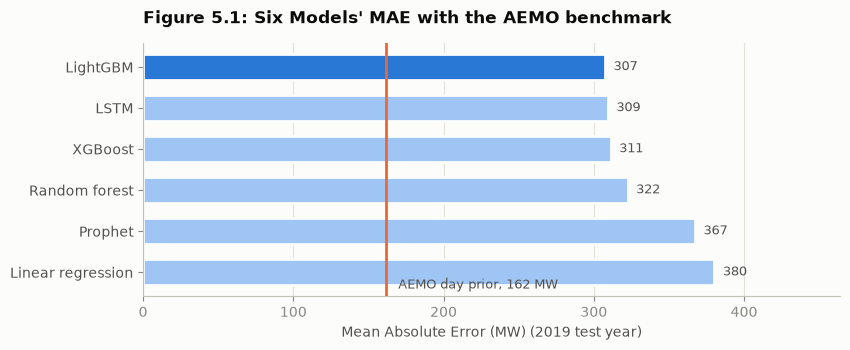

In [17]:
# Figure 5.1: Overall MAE with the AEMO benchmark
overall = mae['overall'].rename(index=NAMES)
aemo_mae = aemo.loc['overall', 'AEMO day prior (MW)']
fig, ax = plt.subplots(figsize=(8.6, 3.6))
y = hbars(ax, overall, overall == overall.min())
ax.axvline(aemo_mae, color=ORANGE, linewidth=2, zorder=3)
ax.text(aemo_mae + 8, y[-1] - 0.3, f'AEMO day prior, {aemo_mae:,.0f} MW', color=INK2, fontsize=9, va='center')
ax.set_xlim(0, overall.max() * 1.22)
ax.set_xlabel('Mean Absolute Error (MW) (2019 test year)')
finish(fig, ax, 'Figure 5.1: Six Models\' MAE with the AEMO benchmark')

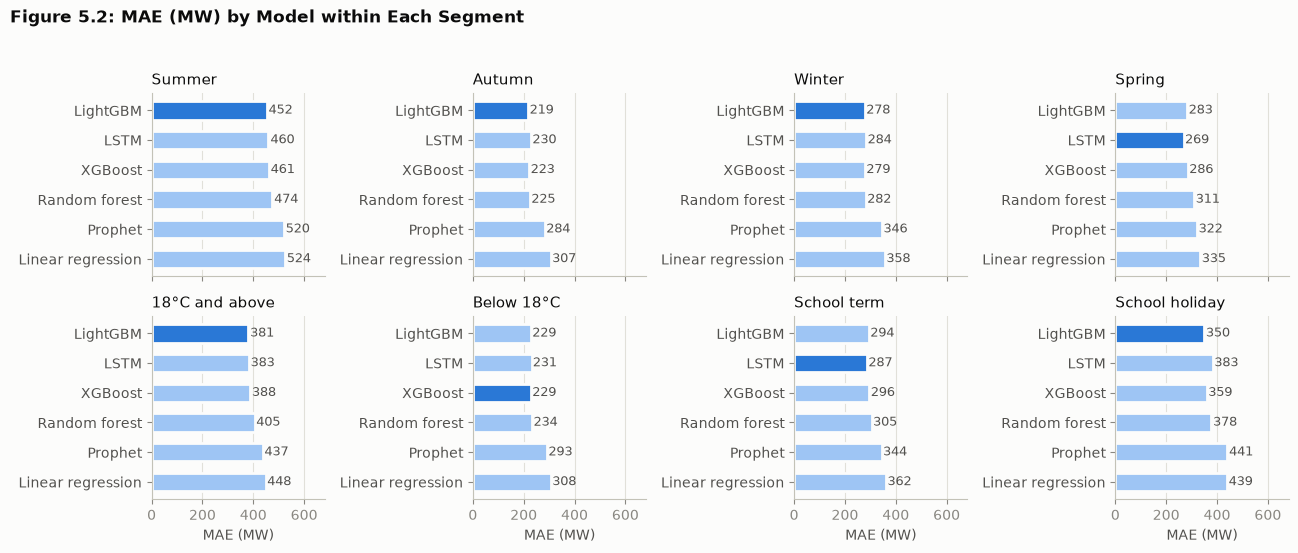

In [18]:
# Figure 5.2: MAE by segment (one panel per segment)
fig, axes = plt.subplots(2, 4, figsize=(13, 5.6), sharex=True)
for ax, s in zip(axes.ravel(), [s for s in SEGMENTS if s != 'overall']):
    values = mae[s].rename(index=NAMES)
    hbars(ax, values, values == values.min())
    ax.set_title(SEGMENTS[s], fontsize=10.5, loc='left', color=INK, pad=6)
ax.set_xlim(0, mae.drop(columns='overall').max().max() * 1.3)
for ax in axes[1]: ax.set_xlabel('MAE (MW)')
fig.suptitle('Figure 5.2: MAE (MW) by Model within Each Segment ', fontsize=12.5, fontweight='bold', x=0.005,
             ha='left', color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

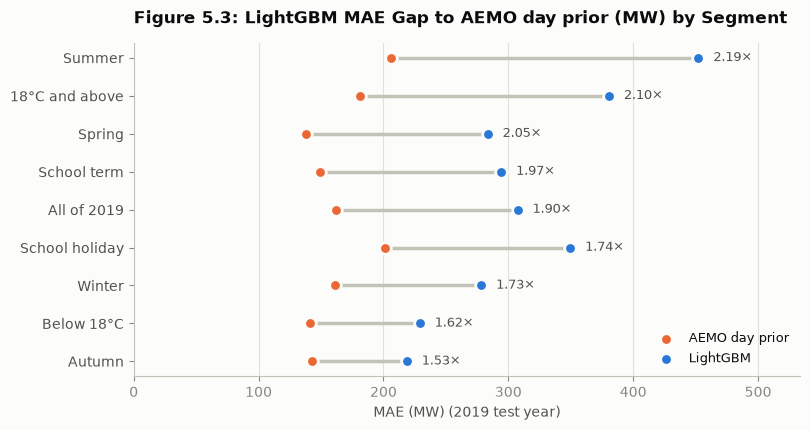

In [19]:
# Figure 5.3: LightGBM (MW)'s Gap to AEMO by segment (sorted by the ratio)
g = table_58.sort_values('Ratio')
y = np.arange(len(g))
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.hlines(y, g['AEMO day prior (MW)'], g['LightGBM (MW)'], color=AXIS, linewidth=2.5, zorder=1)
ax.scatter(g['AEMO day prior (MW)'], y, s=70, color=ORANGE, edgecolor=SURFACE, linewidth=2, zorder=3, label='AEMO day prior')
ax.scatter(g['LightGBM (MW)'], y, s=70, color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=3, label='LightGBM')
for yi, (lg, ratio) in zip(y, g[['LightGBM (MW)', 'Ratio']].values):
    ax.text(lg + 12, yi, f'{ratio:.2f}×', va='center', fontsize=9, color=INK2)
ax.set_yticks(y)
ax.set_yticklabels(g.index.map(SEGMENTS), color=INK2)
ax.set_xlim(0, g['LightGBM (MW)'].max() * 1.18)
ax.set_xlabel('MAE (MW) (2019 test year)')
ax.xaxis.grid(True); ax.set_axisbelow(True)
ax.legend(loc='lower right', frameon=False, fontsize=9)
finish(fig, ax, 'Figure 5.3: LightGBM MAE Gap to AEMO day prior (MW) by Segment')

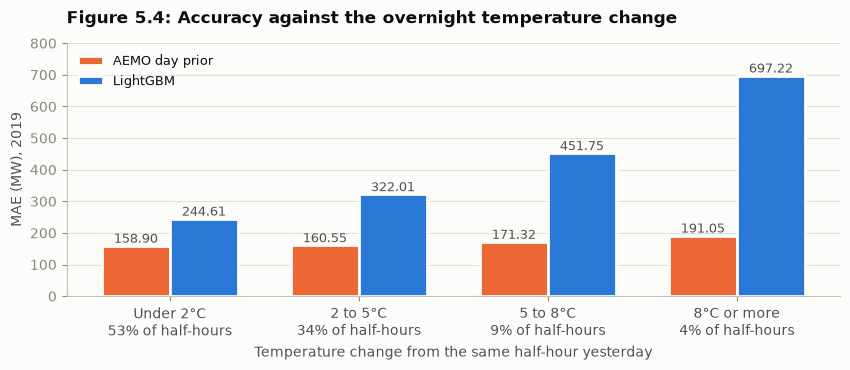

In [20]:
# Figure 5.4: Accuracy against the overnight temperature change
x, w = np.arange(len(table_59)), 0.36
fig, ax = plt.subplots(figsize=(8.6, 3.8))
for offset, col, colour in [(-w / 2, 'AEMO day prior (MW)', ORANGE), (w / 2, 'LightGBM (MW)', BLUE)]:
    ax.bar(x + offset, table_59[col], w, color=colour, edgecolor=SURFACE, linewidth=2, label=col.replace(' (MW)', ''))
    for xi, v in zip(x, table_59[col]):
        ax.text(xi + offset, v + 10, f'{v:.2f}', ha='center', fontsize=9, color=INK2)
ax.set_xticks(x)
ax.set_xticklabels([f'{b}\n{s:.0f}% of half-hours' for b, s in table_59['Share (%)'].items()], color=INK2)
ax.set_xlabel('Temperature change from the same half-hour yesterday')
ax.set_ylabel('MAE (MW), 2019')
ax.set_ylim(0, table_59['LightGBM (MW)'].max() * 1.15)
ax.yaxis.grid(True); ax.set_axisbelow(True)
ax.legend(frameon=False, loc='upper left', fontsize=9)
finish(fig, ax, 'Figure 5.4: Accuracy against the overnight temperature change')

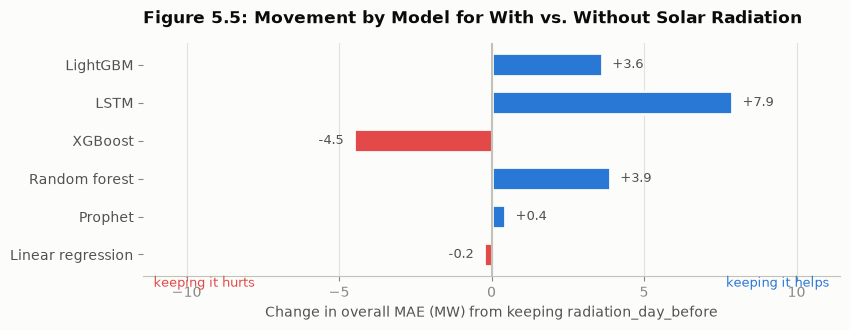

In [21]:
# Figure 5.5: Effect of radiation_day_before
change_mw = table_510.loc[MODELS, 'Change (MW)'].rename(index=NAMES)
y, lim = np.arange(len(change_mw))[::-1], change_mw.abs().max() * 1.45
fig, ax = plt.subplots(figsize=(8.6, 3.4))
ax.barh(y, change_mw, height=0.6, color=[BLUE if v > 0 else RED for v in change_mw], edgecolor=SURFACE, linewidth=2)
ax.axvline(0, color=AXIS, linewidth=1.5, zorder=3)
for yi, v in zip(y, change_mw):
    ax.text(v + (0.35 if v >= 0 else -0.35), yi, f'{v:+.1f}', va='center', fontsize=9.5, color=INK2, ha='left' if v >= 0 else 'right')
ax.set_yticks(y)
ax.set_yticklabels(change_mw.index, color=INK2)
ax.set_xlim(-lim, lim)
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel('Change in overall MAE (MW) from keeping radiation_day_before')
ax.text(lim * 0.97, y[-1] - 0.85, 'keeping it helps', color=BLUE, fontsize=9, ha='right')
ax.text(-lim * 0.97, y[-1] - 0.85, 'keeping it hurts', color=RED, fontsize=9, ha='left')
finish(fig, ax, 'Figure 5.5: Movement by Model for With vs. Without Solar Radiation')